In [1]:
#我对2025年8月30日15：45的零一个冕环增量事件画个图看看他的时间和过程
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter1d

In [4]:
#重新用PYTHON画了一下131的图
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20250830\\*.fits')
file_list.sort()
out_path=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20250830_fig\\'

for i in range(len(file_list)):
    map_aia=sunpy.map.Map(file_list[i])
    bottom_left=SkyCoord(Tx=-50*u.arcsec,Ty=-600*u.arcsec,frame=map_aia.coordinate_frame)
    top_right=SkyCoord(Tx=250*u.arcsec,Ty=-300*u.arcsec,frame=map_aia.coordinate_frame)
    smap1=map_aia.submap(bottom_left,top_right=top_right)
    fig=plt.figure(figsize=(10,10))
    ax=fig.add_subplot(projection=smap1)
    old_norm=smap1.plot_settings['norm']
    old_norm.vmin=0.01
    old_norm.vmax=2000
    smap1.plot(axes=ax,norm=old_norm)
    plt.savefig(out_path+f'{i:03d}.png',dpi=100)
    plt.close()

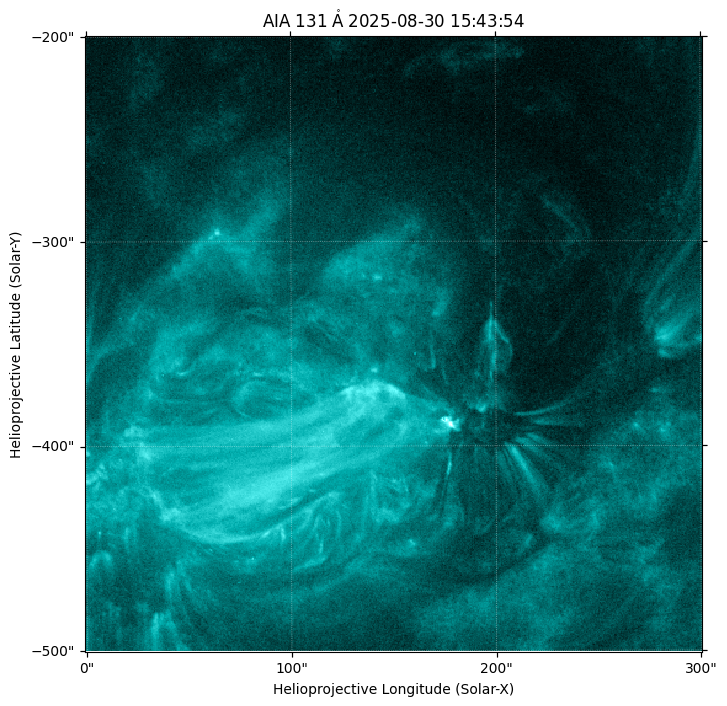

In [ ]:
aia_map=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20250830\aia.lev1_euv_12s.2025-08-30T154356Z.131.image_lev1.fits')
bottom_left=SkyCoord(Tx=-50*u.arcsec,Ty=-600*u.arcsec,frame=aia_map.coordinate_frame)
top_right=SkyCoord(Tx=250*u.arcsec,Ty=-300*u.arcsec,frame=aia_map.coordinate_frame)
smap=aia_map.submap(bottom_left,top_right=top_right)
fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(projection=smap)
smap.plot(axes=ax,cmap='sdoaia131')

In [ ]:
file_path=r'C:\Users\xiao\Downloads\JSOC_20260306_002767\\'
file_list=glob.glob(file_path+'*.94.*')

print(file_list)

['C:\\Users\\xiao\\Downloads\\JSOC_20260306_002767\\aia.lev1_euv_12s.2024-06-18T200001Z.94.image_lev1.fits', 'C:\\Users\\xiao\\Downloads\\JSOC_20260306_002767\\aia.lev1_euv_12s.2024-06-18T200013Z.94.image_lev1.fits', 'C:\\Users\\xiao\\Downloads\\JSOC_20260306_002767\\aia.lev1_euv_12s.2024-06-18T200027Z.94.image_lev1.fits', 'C:\\Users\\xiao\\Downloads\\JSOC_20260306_002767\\aia.lev1_euv_12s.2024-06-18T200049Z.94.image_lev1.fits', 'C:\\Users\\xiao\\Downloads\\JSOC_20260306_002767\\aia.lev1_euv_12s.2024-06-18T200104Z.94.image_lev1.fits', 'C:\\Users\\xiao\\Downloads\\JSOC_20260306_002767\\aia.lev1_euv_12s.2024-06-18T200114Z.94.image_lev1.fits', 'C:\\Users\\xiao\\Downloads\\JSOC_20260306_002767\\aia.lev1_euv_12s.2024-06-18T200134Z.94.image_lev1.fits', 'C:\\Users\\xiao\\Downloads\\JSOC_20260306_002767\\aia.lev1_euv_12s.2024-06-18T200144Z.94.image_lev1.fits', 'C:\\Users\\xiao\\Downloads\\JSOC_20260306_002767\\aia.lev1_euv_12s.2024-06-18T200154Z.94.image_lev1.fits', 'C:\\Users\\xiao\\Downloads